# Example usage of `run_agent_env_sensor_loop`

This notebook shows a minimal, end-to-end call to `run_agent_env_sensor_loop`, including:
- setting sensor and specification parameters
- choosing whether to use pure PID or EKF+PID
- saving and viewing the trajectory plot

In [1]:
from pathlib import Path

# Ensure notebook is running from project root
project_root = Path.cwd()
project_root

PosixPath('/Users/andrewzchen/S-Senior/Winter Quarter/CS 238V/aa228v_finalproject')

In [2]:
import numpy as np
from main import run_agent_env_sensor_loop

In [ ]:
rollout_args = dict(
    mu_z0=0.8,
    sigma_z0=0.02,
    sensor_args=dict(
        # Proposal / sampling distribution
        mu_A=0.1,
        sigma_A=0.1,
        mu_k=2 * np.pi,  # wavelength = k / 2pi
        sigma_k=0.5,
        sigma_eps=0.02,
        p_penetration=0.1,
        alpha_min=0.10,
        alpha_max=10.0,
        perfect_sensing=False,
    ),
)

nominal_rollout_args = dict(
    mu_z0=0.8,
    sigma_z0=0.005,
    sensor_args=dict(
        # Nominal / target distribution used for importance-sampling weights
        mu_A=0.1,
        sigma_A=0.05,
        mu_k=2 * np.pi,
        sigma_k=0.5,
        sigma_eps=0.005,
        p_penetration=0.05,
        alpha_min=0.10,
        alpha_max=10.0,
        perfect_sensing=False,
    ),
)

specification = dict(
    z_min=0.5,
    z_max=1.1,
    pitch_min=-np.deg2rad(15.0),
    pitch_max=np.deg2rad(15.0),
)

trajectory_path = "plots/plane_trajectory_notebook.png"

In [ ]:
result = run_agent_env_sensor_loop(
    rollout_args=rollout_args,
    nominal_rollout_args=nominal_rollout_args,
    z_target=0.8,
    n_steps=2000,  # dt = 0.01 s
    seed=42,
    enable_lateral_damper=True,  # fixes lateral instability using aileron
    use_ekf_pid_controller=True,  # set False to run pure PID
    specification=specification,
    ground_effect_enabled=True,
    save_trajectory_plot=True,
    trajectory_plot_path=trajectory_path,
)

print("Sampled z0:", result["z0_sampled"])
print("Rollout log-likelihood:", result["trajectory_log_likelihood_rollout"])
print("Nominal log-likelihood:", result["trajectory_log_likelihood_nominal"])
print("Log importance weight:", result["trajectory_log_importance_weight"])
print("Rollout breakdown:", result["trajectory_log_likelihood_rollout_breakdown"])
print("Nominal breakdown:", result["trajectory_log_likelihood_nominal_breakdown"])

 step    z_true     z_hat    de_pid    de_ekf    da_ekf     z_est   theta_est
------------------------------------------------------------------------
Controller driving env.step: EKF+PID
    0    0.8000    0.7610    0.0156    0.0155   -0.0000    0.7613    -0.00000
   20    0.7952    0.8861   -0.0730   -0.0693    0.0014    0.8762     0.01918
   40    0.8459    0.9683   -0.1205   -0.1190    0.0031    0.9631     0.02616
   60    0.8843    0.9616   -0.0882   -0.0918    0.0042    0.9676     0.01097
   80    0.8805    0.8528   -0.0291   -0.0350    0.0046    0.8640     0.00276
  100    0.8694    0.7437   -0.0061   -0.0113    0.0046    0.7530     0.01278
  120    0.8909    0.7829   -0.0316   -0.0322    0.0044    0.7805     0.01724
  140    0.9154    1.0281   -0.1042   -0.1019    0.0041    1.0173     0.00402
  160    0.8750    0.9683   -0.0605   -0.0633    0.0040    0.9693    -0.00618
  180    0.8485    0.6816    0.0201    0.0123    0.0042    0.6945     0.01061
  200    0.8584    0.8469   -0.0

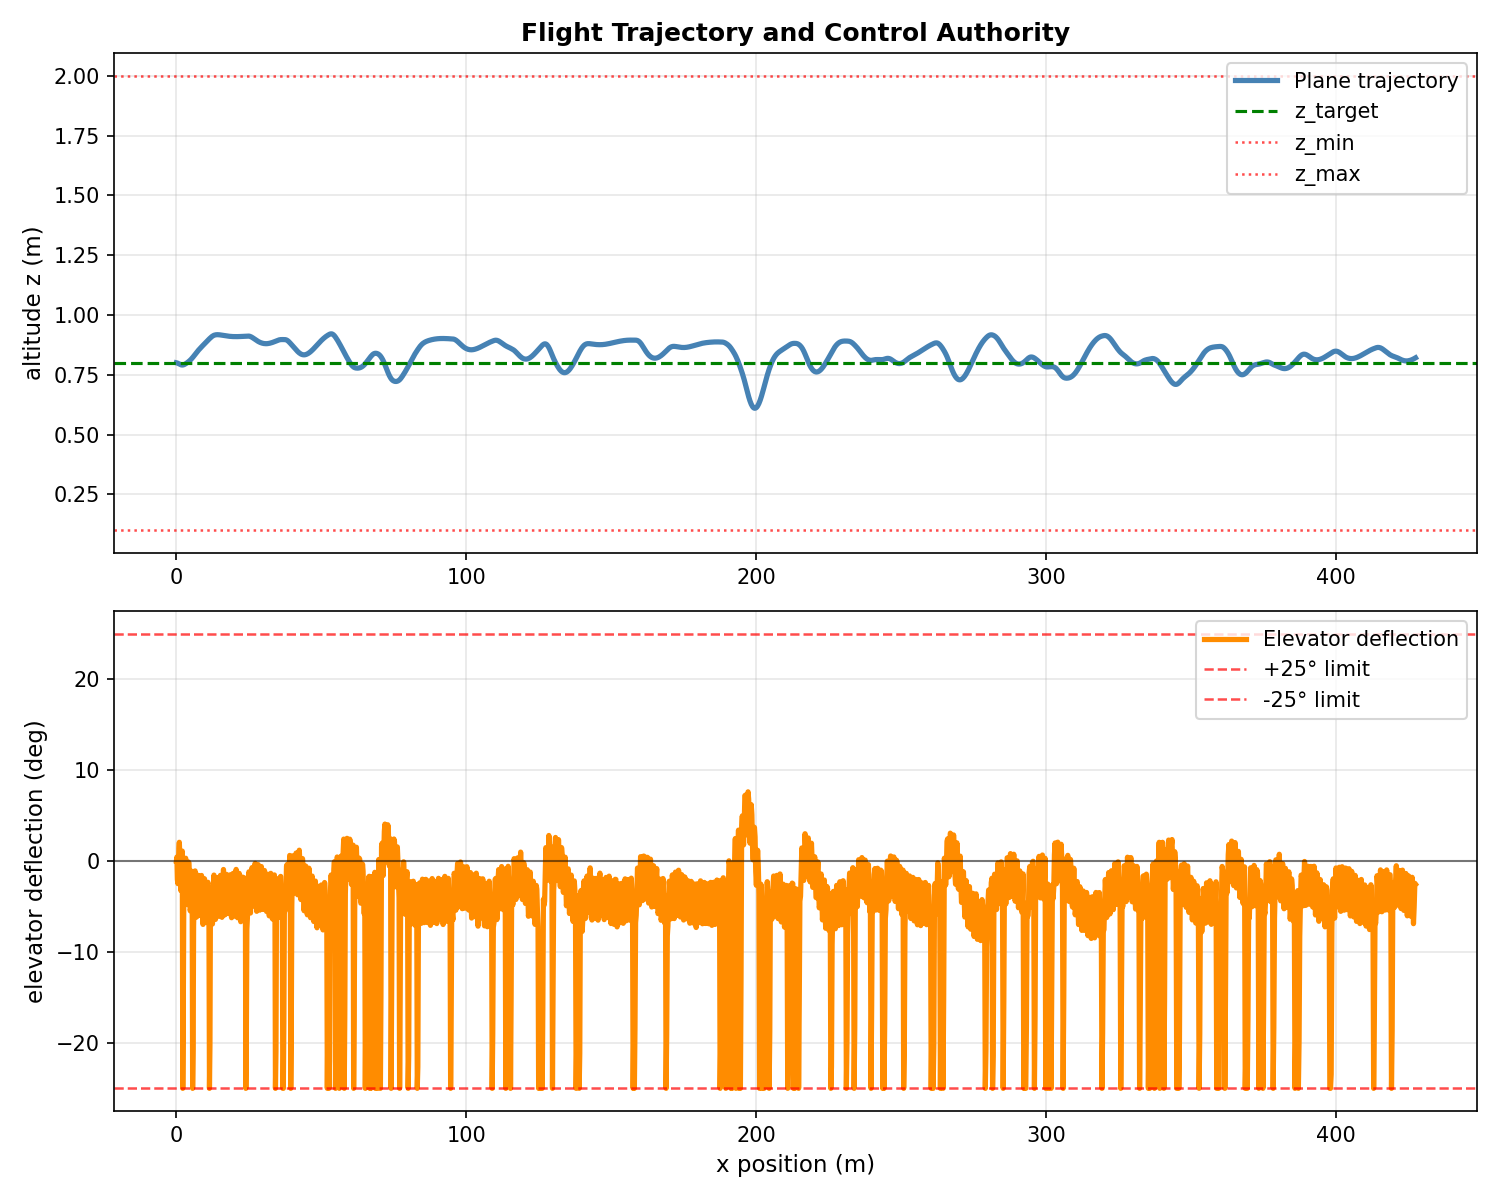

In [5]:
from IPython.display import Image, display

if result.get("trajectory_plot", {}).get("saved", False):
    display(Image(filename=result["trajectory_plot"]["path"]))
else:
    print("Trajectory plot was not saved.")
    print(result.get("trajectory_plot"))

In [ ]:
print("Rollout log-likelihood:", result["trajectory_log_likelihood_rollout"])
print("Nominal log-likelihood:", result["trajectory_log_likelihood_nominal"])
print("Log importance weight:", result["trajectory_log_importance_weight"])

print("\nRollout breakdown:")
print(result["trajectory_log_likelihood_rollout_breakdown"])

print("\nNominal breakdown:")
print(result["trajectory_log_likelihood_nominal_breakdown"])